# 05 — event bars: the catalogue, and any threshold you like

`lake.gold.bars` holds tick, volume and dollar bars at **one canonical threshold per symbol** (`config/bars.yaml`, sized so the busiest venue prints ~100 bars/day). It is the dataset a desk is handed: cross-venue comparable, fixed point, every row stamped with the `gold.trades` snapshot it came from. Any other threshold is `k2lake.bars()` over `gold.trades` in DuckDB — same definition, no second table.

A bar is a *cumulative bucket*: trade → bar k of its UTC day when k·T ≤ (the day's total before it) < (k+1)·T. Not a reset-after-crossing bar, on purpose: this form is one window expression in Spark, DuckDB and a twenty-line Python reference, and the three agree at tolerance zero (`scripts/parity-bars.sh`).

In [1]:
from k2lake import connect, bars, SCALE
con = connect()
con.sql("SELECT bar_kind, exchange, count(*) AS bars, min(day) AS first_day, max(day) AS last_day FROM lake.gold.bars GROUP BY ALL ORDER BY 1, 2").show()

┌──────────┬──────────┬───────┬────────────┬────────────┐
│ bar_kind │ exchange │ bars  │ first_day  │  last_day  │
│ varchar  │ varchar  │ int64 │    date    │    date    │
├──────────┼──────────┼───────┼────────────┼────────────┤
│ dollar   │ binance  │   889 │ 2026-08-26 │ 2026-08-27 │
│ dollar   │ coinbase │   862 │ 2026-08-26 │ 2026-08-27 │
│ dollar   │ kraken   │   370 │ 2026-08-26 │ 2026-08-27 │
│ tick     │ binance  │   817 │ 2026-08-26 │ 2026-08-27 │
│ tick     │ coinbase │   809 │ 2026-08-26 │ 2026-08-27 │
│ tick     │ kraken   │   137 │ 2026-08-26 │ 2026-08-27 │
│ volume   │ binance  │   878 │ 2026-08-26 │ 2026-08-27 │
│ volume   │ coinbase │   747 │ 2026-08-26 │ 2026-08-27 │
│ volume   │ kraken   │   287 │ 2026-08-26 │ 2026-08-27 │
└──────────┴──────────┴───────┴────────────┴────────────┘



BTC/USD dollar bars on the two venues that quote it in USD. Each bar is ~$6 M of notional; Coinbase prints three of them for every one Kraken does, which is the liquidity difference showing rather than a threshold to tune.

In [2]:
con.sql(f"""
SELECT exchange, bar_seq, open_time, close_time,
       open_e8 / {SCALE} AS open, close_e8 / {SCALE} AS close,
       volume_e8 / {SCALE} AS volume, quote_volume_e8 / {SCALE} AS quote_volume, trade_count,
       epoch(close_time) - epoch(open_time) AS seconds
FROM lake.gold.bars
WHERE canonical_symbol = 'BTC/USD' AND bar_kind = 'dollar' AND day = DATE '2026-08-26'
ORDER BY exchange, bar_seq
""").show(max_rows=12)

┌──────────┬─────────┬───────────────────────────────┬───────────────────────────────┬──────────┬──────────┬─────────────┬──────────────────┬─────────────┬────────────────────┐
│ exchange │ bar_seq │           open_time           │          close_time           │   open   │  close   │   volume    │   quote_volume   │ trade_count │      seconds       │
│ varchar  │  int32  │   timestamp with time zone    │   timestamp with time zone    │  double  │  double  │   double    │      double      │    int64    │       double       │
├──────────┼─────────┼───────────────────────────────┼───────────────────────────────┼──────────┼──────────┼─────────────┼──────────────────┼─────────────┼────────────────────┤
│ coinbase │       0 │ 2026-08-26 12:32:53.904315+00 │ 2026-08-26 12:49:56.519041+00 │ 78425.02 │ 78292.82 │ 76.64596563 │ 6001970.75478094 │       35061 │ 1022.6147260665894 │
│ coinbase │       1 │ 2026-08-26 12:49:56.811771+00 │ 2026-08-26 13:04:56.314951+00 │ 78292.82 │  78278.1 │  76.96

Bar duration is the point of an event bar: it shrinks when the market is busy and stretches when it is quiet, so each bar carries roughly the same information. Time bars (`gold.ohlcv_*`) do the opposite.

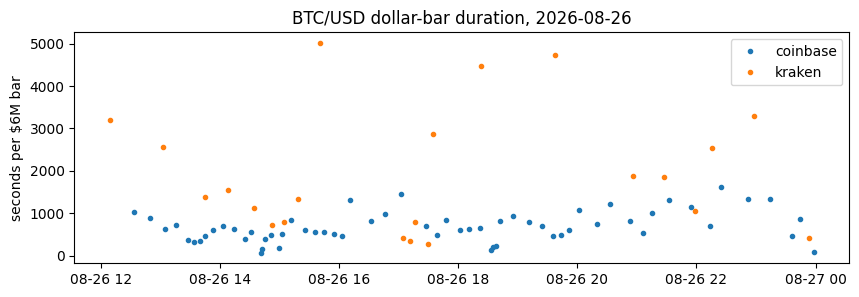

In [3]:
import matplotlib.pyplot as plt
df = con.sql("""
SELECT exchange, open_time, epoch(close_time) - epoch(open_time) AS seconds
FROM lake.gold.bars WHERE canonical_symbol = 'BTC/USD' AND bar_kind = 'dollar' AND day = DATE '2026-08-26'
""").df()
fig, ax = plt.subplots(figsize=(10, 3))
for ex, g in df.groupby('exchange'):
    ax.plot(g['open_time'], g['seconds'], marker='.', linestyle='', label=ex)
ax.set_ylabel('seconds per $6M bar'); ax.set_title('BTC/USD dollar-bar duration, 2026-08-26'); ax.legend()
plt.show()

Any other threshold is a function, not a table. `bars()` runs the same window SQL over `gold.trades` in DuckDB; here $1 M bars for one venue, one day — ~6× as many rows as the catalogue's $6 M bars.

In [4]:
con.sql("SELECT count(*) AS catalogue_bars FROM lake.gold.bars WHERE canonical_symbol = 'BTC/USD' AND exchange = 'coinbase' AND bar_kind = 'dollar' AND day = DATE '2026-08-26'").show()
adhoc = bars(con, 'dollar', 1_000_000, symbol='BTC/USD', exchange='coinbase', start='2026-08-26', end='2026-08-27')
adhoc.aggregate('count(*) AS adhoc_bars').show()
adhoc.limit(5).show()

┌────────────────┐
│ catalogue_bars │
│     int64      │
├────────────────┤
│             60 │
└────────────────┘



┌────────────┐
│ adhoc_bars │
│   int64    │
├────────────┤
│        355 │
└────────────┘



┌──────────┬──────────────────┬──────────┬──────────────┬────────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬─────────────────┬─────────────┬───────────────────────────────┬───────────────────────────────┐
│ exchange │ canonical_symbol │ bar_kind │  threshold   │    day     │ bar_seq │    open_e8    │    high_e8    │    low_e8     │   close_e8    │ volume_e8  │ quote_volume_e8 │ trade_count │           open_time           │          close_time           │
│ varchar  │     varchar      │ varchar  │ decimal(8,1) │    date    │  int32  │     int64     │     int64     │     int64     │     int64     │   int64    │      int64      │    int64    │   timestamp with time zone    │   timestamp with time zone    │
├──────────┼──────────────────┼──────────┼──────────────┼────────────┼─────────┼───────────────┼───────────────┼───────────────┼───────────────┼────────────┼─────────────────┼─────────────┼───────────────────────────────┼─────────────────

The catalogue is reproducible by construction: `bars()` at the catalogue's own threshold returns the catalogue's rows. This cell is the parity check `scripts/parity-bars.sh` runs across every symbol and every kind, in miniature.

In [5]:
mine = bars(con, 'dollar', 6_000_000, symbol='BTC/USD', start='2026-08-26', end='2026-08-27').df()
theirs = con.sql("SELECT exchange, canonical_symbol, bar_kind, day, bar_seq, open_e8, high_e8, low_e8, close_e8, volume_e8, quote_volume_e8, trade_count, open_time, close_time FROM lake.gold.bars WHERE canonical_symbol = 'BTC/USD' AND bar_kind = 'dollar' AND day = DATE '2026-08-26' ORDER BY exchange, bar_seq").df()
cols = ['exchange', 'bar_seq', 'open_e8', 'high_e8', 'low_e8', 'close_e8', 'volume_e8', 'quote_volume_e8', 'trade_count']
same = mine[cols].reset_index(drop=True).equals(theirs[cols].reset_index(drop=True))
print(len(mine), 'bars from bars(),', len(theirs), 'in the catalogue, identical:', same)
assert same

82 bars from bars(), 82 in the catalogue, identical: True
